## Karnataka patch based modelling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from compartments import CompartmentPatchArray, SEIRV_patch_stepper
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from numpy.typing import NDArray
# Set the animation display to 'jshtml'
rc('animation', html='jshtml')


In [ ]:

def animate_bar(
        target_feature:NDArray,
        x_bar: NDArray|list,
        STEPS: int,
        figsize:tuple = (10, 6)
    ):
    """
    Parameters
    ----------
        target_feature: 
    """
    fig, ax = plt.subplots(figsize=figsize)
    # Initial plot state (using the first time step)
    bars = ax.bar(x_bar, target_feature[0, :], color='skyblue', edgecolor='navy')

    # Styling the plot
    ax.set_ylim(0, np.max(target_feature) * 1.2) # Set y-axis limits
    ax.set_xlabel('Age Groups')
    ax.set_ylabel('Number of Infections')
    ax.set_title('Step 0: Distribution across Age Groups')

    # 3. Define the Animation Update Function
    def update(frame):
        # Update the height of each bar for the current frame
        vals = target_feature[frame, :]
        for bar, val in zip(bars, vals):
            bar.set_height(val)
        
        # Update title to show progress
        ax.set_title(f'Step {frame}: Distribution across Age Groups')
        return bars

    # 4. Create and Save the Animation
    # 'blit=True' ensures only the parts of the plot that have changed are redrawn
    ani = FuncAnimation(fig, update, frames=STEPS, interval=100, blit=True)

    # To save as a GIF (requires 'pillow' library)
    # ani.save('distribution_animation.gif', writer='pillow', fps=10)
    return ani

NameError: name 'NDArrray' is not defined

In [ ]:
WEIBULL_WANING_SHAPE = 3.7
WEIBULL_WANING_SCALE = 120
VACCINE_EFFICACY = 0.66

### Population Projected Data

In [ ]:
population_data_file = 'karnataka-data/age_dist_projected_karnataka.csv'
population_df_age = pd.read_csv(population_data_file)

In [ ]:
population_df_age.head()

,Age group,Population
0,0-4,4660
1,5-9,5023
2,10-14,5070
3,15-19,5355
4,20-24,5706


In [ ]:
popdatafile = "karnataka-data/finalPopulationData.xlsx"
population_district_2011 = pd.read_excel(popdatafile)
initial_population = population_district_2011[['district', 'Cowin Population']]
# initial_population = np.array(initial_population)
initial_population.head()

,district,Cowin Population
0,Kodagu,400000
1,Bagalakote,1362000
2,Ballari,2068000
3,Belagavi,3566000
4,Bengaluru Rural,819000


In [ ]:
b = population_district_2011['district']
b = sorted(b)

In [ ]:
initial_population.head()

,district,Cowin Population
0,Kodagu,400000
1,Bagalakote,1362000
2,Ballari,2068000
3,Belagavi,3566000
4,Bengaluru Rural,819000


### Loading the karnatatka cases district data

In [ ]:
karnataka_data_filename = 'karnataka-data/IRDD_allka.csv'
karnataka_dataframe = pd.read_csv(karnataka_data_filename)
karnataka_dataframe.head()

,Date,District,Infected,Recovered,Deceased
0,22-03-2020,Bagalakote,0,0,0
1,23-03-2020,Bagalakote,0,0,0
2,24-03-2020,Bagalakote,0,0,0
3,25-03-2020,Bagalakote,0,0,0
4,26-03-2020,Bagalakote,0,0,0


In [ ]:
karnataka_dataframe[karnataka_dataframe['District']== 'Bagalakote']

,Date,District,Infected,Recovered,Deceased
0,22-03-2020,Bagalakote,0,0,0
1,23-03-2020,Bagalakote,0,0,0
2,24-03-2020,Bagalakote,0,0,0
3,25-03-2020,Bagalakote,0,0,0
4,26-03-2020,Bagalakote,0,0,0
...,...,...,...,...,...
1038,28-01-2023,Bagalakote,0,0,0
1039,29-01-2023,Bagalakote,0,0,0
1040,30-01-2023,Bagalakote,0,0,0
1041,31-01-2023,Bagalakote,0,0,0


In [ ]:
karnataka_dataframe['District'].unique()

<StringArray>
[      'Bagalakote',          'Ballari',         'Belagavi',
  'Bengaluru Rural',  'Bengaluru Urban',            'Bidar',
  'Chamarajanagara',  'Chikkaballapura',   'Chikkamagaluru',
      'Chitradurga', 'Dakshina Kannada',       'Davanagere',
          'Dharwad',            'Gadag',           'Hassan',
           'Haveri',       'Kalaburagi',           'Kodagu',
            'Kolar',           'Koppal',           'Mandya',
           'Mysuru',          'Raichur',       'Ramanagara',
       'Shivamogga',         'Tumakuru',            'Udupi',
   'Uttara Kannada',       'Vijayapura',          'Yadgiri',
           'Others',        'Karnataka']
Length: 32, dtype: str

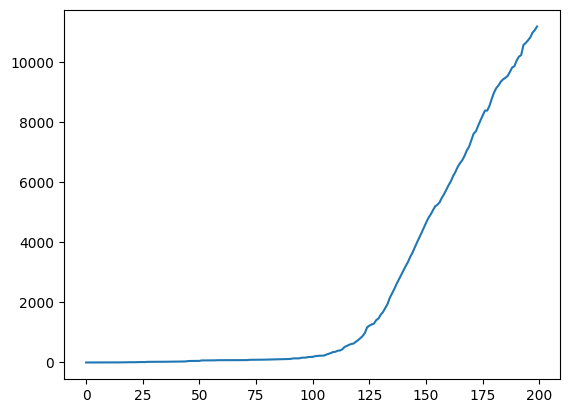

In [ ]:
%matplotlib inline
plt.clf()
bagalakote_state = karnataka_dataframe[karnataka_dataframe['District']=='Bagalakote'] #'Infected']
bagalakote_infected = bagalakote_state['Infected']
bagalakote_recovered = bagalakote_state['Recovered'] +bagalakote_state['Deceased']
(bagalakote_infected.iloc[:200]).plot()
plt.show()

### Age Distribution
Pulling out the age distibution of karnataka and then defining the initial pach conditions

In [ ]:
age_distribution = pd.read_csv('karnataka-data/age_dist_projected_karnataka.csv')
age_fraction = np.array(age_distribution['Population'])
age_fraction = age_fraction[:-1]
print(age_fraction)
age_fraction[-2] = age_fraction[-2] + age_fraction[-1]
print(age_fraction)
age_fraction = age_fraction[:-1]
print(age_fraction)
age_fraction = age_fraction/np.sum(age_fraction)
print(np.sum(age_fraction))

[4660 5023 5070 5355 5706 5896 5887 5490 4853 4332 3771 3142 2463 1884
 1467  986  858]
[4660 5023 5070 5355 5706 5896 5887 5490 4853 4332 3771 3142 2463 1884
 1467 1844  858]
[4660 5023 5070 5355 5706 5896 5887 5490 4853 4332 3771 3142 2463 1884
 1467 1844]
0.9999999999999999


### Age stratified Contact Rates

In [ ]:
age_rate_contact_matrix = np.loadtxt('karnataka-data/ageinteractionmat.csv')
age_stratification = [i*5 for i in range(80//5)]

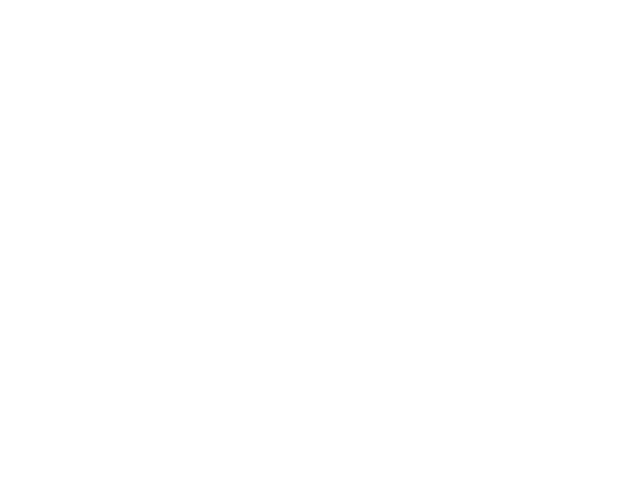

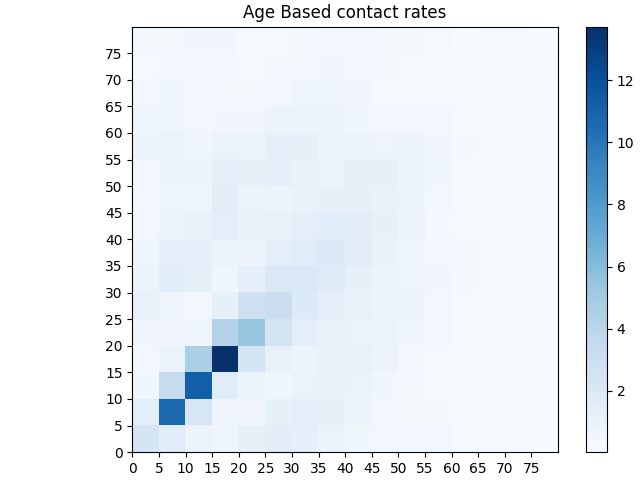

In [ ]:
%matplotlib widget
plt.clf()
fig, axs = plt.subplots(1, 1, constrained_layout = True)
map =axs.imshow(age_rate_contact_matrix, cmap ='Blues', origin='lower')

edge_positions = np.arange(age_rate_contact_matrix.shape[1] ) -0.5
axs.set_xticks(edge_positions)
axs.set_yticks(edge_positions)

axs.set_yticklabels(age_stratification)
axs.set_xticklabels(age_stratification)
axs.set_title('Age Based contact rates')
plt.colorbar(mappable=map, ax=axs)
# plt.show()

In [ ]:
%matplotlib inline
age_rate_contact_matrix[:3, :3]

array([[ 2.35304901,  1.59193637,  0.81654634],
       [ 1.39768618, 10.63984555,  2.22042518],
       [ 0.54450173,  3.37757919, 11.262449  ]])

### Loading the contact rate values from the paper

##### Checking the Bagalkote infection growth before vaccination starts
We assume that the districts do not interact with each other, we shall look into the district of bagalkote with patches being defined by the age stratification and the age groups.

In [ ]:
ALPHA = 1/5.8
GAMMA = 1/5

In [ ]:
betas_patch_dataframe = pd.read_csv("karnataka-data/betas_paper.csv")

In [ ]:
a = betas_patch_dataframe['Unit'].unique()[8:]
a = sorted(a)
b = sorted(b)
for i in range(len(a)):
    betas_patch_dataframe.loc[betas_patch_dataframe["Unit"] == a[i], "Unit"] = b[i]
betas_patch_dataframe = betas_patch_dataframe.iloc[8:]
betas_patch_dataframe =betas_patch_dataframe.rename(columns={'Unit':'district'})

In [ ]:
betas_patch_dataframe.head()

,district,T1,T2,T3,T4,T5
8,Bagalakote,0.006,0.017,0.018,0.008,0.043
9,Ballari,0.010,0.025,0.057,0.015,0.056
10,Belagavi,0.013,0.025,0.032,0.012,0.046
11,Bengaluru Rural,0.019,0.025,0.061,0.046,0.049
12,Ramanagara,0.018,0.024,0.045,0.030,0.042


Here i have been  abit lazy and just have used the contact rates for the time window denoted as 'T1' in the paper throughout

In [ ]:
bagalkote_contact_first_45 = float(betas_patch_dataframe[betas_patch_dataframe['district']=='Bagalakote']['T1'].iloc[0])
bagalkote_contact_rest_no_Vacc = float(betas_patch_dataframe[betas_patch_dataframe['district']=='Bagalakote']['T2'].iloc[0])
# print(f'The contact rate used for the Bagalakote Test {bagalkote_contact_first_200}')

No vaccination condition in bagalkote with no interacting districts

In [ ]:
bagalakote_state_inits = bagalakote_state
bagalakote_state_inits.head()

,Date,District,Infected,Recovered,Deceased
0,22-03-2020,Bagalakote,0,0,0
1,23-03-2020,Bagalakote,0,0,0
2,24-03-2020,Bagalakote,0,0,0
3,25-03-2020,Bagalakote,0,0,0
4,26-03-2020,Bagalakote,0,0,0


In [ ]:
bagalakote_state_inits['Date'] = pd.to_datetime(bagalakote_state_inits['Date'])
init_date = '2020-09-16'
bagalakote_state_inits = bagalakote_state_inits[bagalakote_state_inits['Date']>=init_date]
bagalakote_state_inits.head()

/tmp/ipykernel_820624/242559061.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  bagalakote_state_inits['Date'] = pd.to_datetime(bagalakote_state_inits['Date'])


,Date,District,Infected,Recovered,Deceased
178,2020-09-16,Bagalakote,8547,6948,89
179,2020-09-17,Bagalakote,8781,7619,93
180,2020-09-18,Bagalakote,8987,7731,96
181,2020-09-19,Bagalakote,9139,7785,97
182,2020-09-20,Bagalakote,9229,7891,98


In [ ]:
bagalakote_infected = bagalakote_state_inits['Infected']
bagalakote_recovered = bagalakote_state_inits['Recovered']+ bagalakote_state_inits['Deceased']
bagalakote_infected = np.array(bagalakote_infected)[:200]
bagalakote_recovered = np.array(bagalakote_recovered)[:200]
# bagalakote_recovered_per_day = np.concatenate((np.array((0,)), np.diff(bagalakote_recovered)))
# print(np.diff(bagalakote_recovered[:5]))
# print(bagalakote_recovered_per_day[:5])
bagalakote_infected_t = (bagalakote_infected - bagalakote_recovered)*30

In [ ]:
bagalakote_population = float(population_district_2011[population_district_2011['district']=='Bagalakote']['Cowin Population'].iloc[0])

BGALKOTE_RECOVERED_RATIO = 4.1/100 # FROM THE IgG data https://www.medrxiv.org/content/10.1101/2020.12.04.20243949v1.full.pdf
BAGALKOTE_INIT_RECOVERED = BGALKOTE_RECOVERED_RATIO * bagalakote_population
BAGALKOTEINITINFECTION = bagalakote_infected_t[0] # TAKEN FROM https://www.medrxiv.org/content/10.1101/2020.12.04.20243949v1.full.pdf
BAGALKOTE_INIT_EXPOSED = 0 #BAGALKOTEINITINFECTION* GAMMA/ALPHA# ALPHA E = I
BAGALKOTE_INIT_SUSCEPTIBLES = bagalakote_population - BAGALKOTEINITINFECTION - BAGALKOTE_INIT_RECOVERED - BAGALKOTE_INIT_EXPOSED

print(f"--- Bagalkote SEIR Initial Conditions ---")
print(f"Total Population:    {bagalakote_population:,.0f}")
print(f"Total Population*0.097:    {bagalakote_population*0.097:,.0f}")
print(f"Recovered Ratio:     {BGALKOTE_RECOVERED_RATIO:.2}")
print(f"Initial Recovered:   {BAGALKOTE_INIT_RECOVERED:,.0f}")
print(f"Initial Infected:    {BAGALKOTEINITINFECTION:,.0f}")
print(f"Initial Exposed:     {BAGALKOTE_INIT_EXPOSED:,.0f}")
print(f"Initial Susceptible: {BAGALKOTE_INIT_SUSCEPTIBLES:,.0f}")
print(f"-----------------------------------------")
#  sprinkle the infection and susceptibles to each age patch
patches_susceptibles = BAGALKOTE_INIT_SUSCEPTIBLES * age_fraction
patches_INFECTED = BAGALKOTEINITINFECTION* age_fraction
patches_RECOVERED = BAGALKOTE_INIT_RECOVERED * age_fraction
patches_EXPOSED = BAGALKOTE_INIT_EXPOSED* age_fraction

bagalakote_init_condition = np.zeros((age_fraction.shape[0], 5))
bagalakote_init_condition[:, 0] = patches_susceptibles
bagalakote_init_condition[:, 1] = patches_EXPOSED
bagalakote_init_condition[:, 2] = patches_INFECTED
bagalakote_init_condition[:, 3] = patches_RECOVERED


--- Bagalkote SEIR Initial Conditions ---
Total Population:    1,362,000
Total Population*0.097:    132,114
Recovered Ratio:     0.041
Initial Recovered:   55,842
Initial Infected:    45,300
Initial Exposed:     0
Initial Susceptible: 1,260,858
-----------------------------------------


In [ ]:
import warnings
warnings.filterwarnings(action="error", category=RuntimeWarning)

In [ ]:
# bagalkote_test_contact_rates= 
NUMPATCHES = 16
bagalakote_patch_arr = CompartmentPatchArray(
    state=bagalakote_init_condition,
    num_patches= NUMPATCHES,
    num_compartments=5,
    iter_num=0
)
STEPS = 200
STEPS_1 = 20
STEPS_2 = STEPS-STEPS_1
states = [np.copy(bagalakote_init_condition)]
contact_rate_bagalakote = [np.ones(NUMPATCHES)*bagalkote_contact_first_45, np.ones(NUMPATCHES)*bagalkote_contact_rest_no_Vacc]
vaccinations_patches_no_vaccine_condition = np.zeros(NUMPATCHES)
print(f'Bagalkote patch array{ bagalakote_patch_arr.state[:5,:]}')
print(f'contact_rates { contact_rate_bagalakote}')
for i in range(STEPS_1):
    # print(i);
    step = SEIRV_patch_stepper(
        compartment_patch_array=bagalakote_patch_arr,
        alpha= ALPHA,
        gamma=GAMMA,
        vaccination_14_days_prior= vaccinations_patches_no_vaccine_condition,
        vaccine_efficacy= VACCINE_EFFICACY,
        betas_patches = contact_rate_bagalakote[0],
        network_matrix= age_rate_contact_matrix,
        waning_weibull_scale= WEIBULL_WANING_SCALE,
        waning_weibull_shape=WEIBULL_WANING_SHAPE
    )
    bagalakote_patch_arr.update_state(bagalakote_patch_arr.state + step)
    assert np.all(np.isclose(np.sum(states[-1], axis= 1), np.sum(states[0], axis = 1)))
    states.append(bagalakote_patch_arr.get_copy_of_the_state())
print(f'Bagalkote patch array{ bagalakote_patch_arr.state[:5,:]}')

for i in range(STEPS_2):
    # print(i);
    step = SEIRV_patch_stepper(
        compartment_patch_array=bagalakote_patch_arr,
        alpha= ALPHA,
        gamma=GAMMA,
        vaccination_14_days_prior= vaccinations_patches_no_vaccine_condition,
        vaccine_efficacy= VACCINE_EFFICACY,
        betas_patches = contact_rate_bagalakote[1],
        network_matrix= age_rate_contact_matrix,
        waning_weibull_scale= WEIBULL_WANING_SCALE,
        waning_weibull_shape=WEIBULL_WANING_SHAPE
    )
    bagalakote_patch_arr.update_state(bagalakote_patch_arr.state + step)
    assert np.all(np.isclose(np.sum(states[-1], axis= 1), np.sum(states[0], axis = 1)))
    states.append(bagalakote_patch_arr.get_copy_of_the_state())

Bagalkote patch array[[ 87901.47479916      0.           3158.11678111   3893.05865984
       0.        ]
 [ 94748.73560433      0.           3404.12459046   4196.31623356
       0.        ]
 [ 95635.29554329      0.           3435.97684125   4235.58098829
       0.        ]
 [101011.24410933      0.           3629.12346843   4473.67577757
       0.        ]
 [107632.1491854       0.           3866.99878821   4766.90830753
       0.        ]]
contact_rates [array([0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006,
       0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006]), array([0.017, 0.017, 0.017, 0.017, 0.017, 0.017, 0.017, 0.017, 0.017,
       0.017, 0.017, 0.017, 0.017, 0.017, 0.017, 0.017])]
Bagalkote patch array[[ 88450.3267496     242.22685135    309.16238879   5950.93425038
       0.        ]
 [ 93939.28020579    506.60698166    588.98583065   7314.30341025
       0.        ]
 [ 94589.34297183    569.4476889     644.39913857   7503.66357353
       0.        ]
 [ 989

(201, 16, 5)
(201, 5)


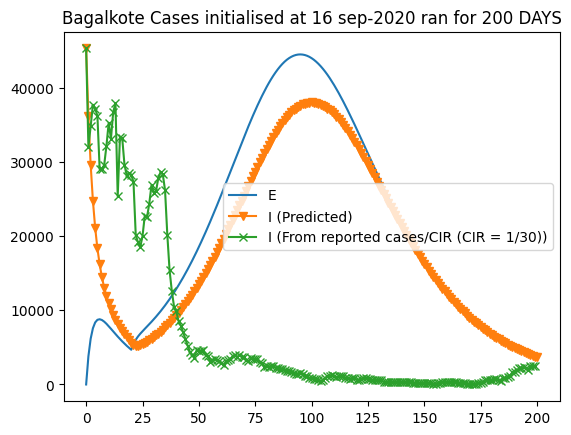

In [ ]:
%matplotlib inline
# %matplotlib widget
plt.clf()
states = np.array(states)
print(states.shape)
total_across_patches_bagalakote = states.sum(axis=1)
print(total_across_patches_bagalakote.shape)
# plt.plot(total_across_patches_bagalakote[:, 0])
# plt.plot(total_across_patches_bagalakote[:, 0], label = 'S')
plt.plot(total_across_patches_bagalakote[:, 1], label = 'E')
plt.plot(total_across_patches_bagalakote[:, 2],marker = 'v', label = 'I (Predicted)')
# plt.plot(total_across_patches_bagalakote[:, 3], label = 'R')
plt.plot(bagalakote_infected_t,  marker ='x', label ='I (From reported cases/CIR (CIR = 1/30))')
# plt.plot(bagalakote_infected,  marker ='x')
plt.title('Bagalkote Cases initialised at 16 sep-2020 ran for 200 DAYS')
plt.legend()
plt.show()


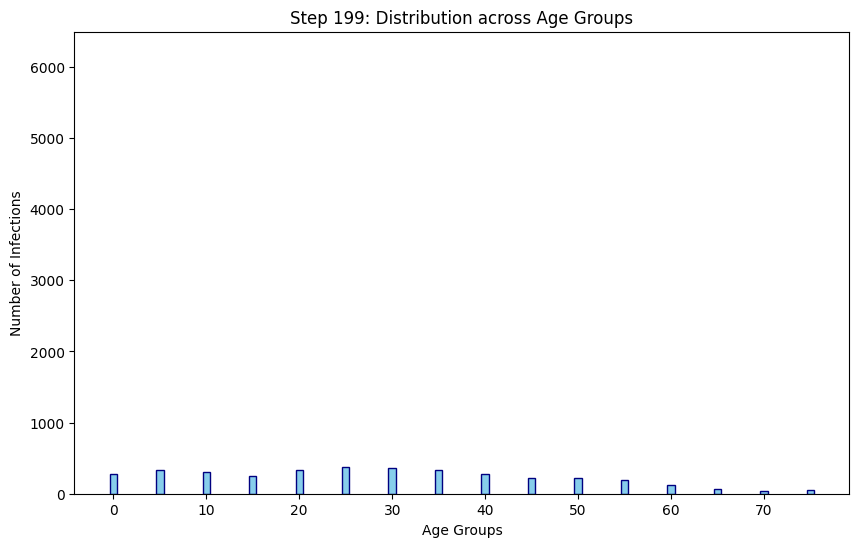

In [ ]:
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots(figsize=(10, 6))

# Define the data slice to plot: A[:, :, 2]
target_feature = states[:, :, 2]

# Initial plot state (using the first time step)
bars = ax.bar(age_stratification, target_feature[0, :], color='skyblue', edgecolor='navy')

# Styling the plot
ax.set_ylim(0, np.max(target_feature) * 1.2) # Set y-axis limits
ax.set_xlabel('Age Groups')
ax.set_ylabel('Number of Infections')
ax.set_title('Step 0: Distribution across Age Groups')

# 3. Define the Animation Update Function
def update(frame):
    # Update the height of each bar for the current frame
    vals = target_feature[frame, :]
    for bar, val in zip(bars, vals):
        bar.set_height(val)
    
    # Update title to show progress
    ax.set_title(f'Step {frame}: Distribution across Age Groups')
    return bars

# 4. Create and Save the Animation
# 'blit=True' ensures only the parts of the plot that have changed are redrawn
ani = FuncAnimation(fig, update, frames=STEPS, interval=100, blit=True)

# To save as a GIF (requires 'pillow' library)
ani.save('distribution_animation.gif', writer='pillow', fps=10)

plt.show()

#### Testing for Synthetic Copntact Matrices

In [ ]:
age_patch_array = np.zeros((2, 5))
age_patch_array = CompartmentPatchArray( state= age_patch_array, num_patches= 2, num_compartments=5, iter_num = 0)
network_matrix = np.array([[0 ,0], [1, 0]])